# 0. Name & Zid
### Varshitha Kammadanam
### Z2009492

# 1. Maximum Natural Gas Use

In [51]:
import pandas as pd
data = pd.read_csv("http://faculty.cs.niu.edu/~dakoop/cs503-2024sp/a8/ny-county-energy.csv.gz")
data['date'] = pd.to_datetime(data[['year', 'month']].assign(day=1))

### a

In [52]:
natural_gas_data = data[(data['data_field'] == '6_nat_consumption') & (data['data_field_display_name'] == 'Total Consumption (T)')]
max_ng = natural_gas_data.sort_values(by='value',ascending=False).iloc[0]
max_ng[['county_name','year','month']]


county_name    New York
year               2021
month                12
Name: 53568, dtype: object

### b

In [53]:
grouped_ng = natural_gas_data.groupby('county_name').agg(usage_t=('value', 'sum'), accounts_t=('number_of_accounts', 'sum'))
grouped_ng['usage_per_account'] = grouped_ng['usage_t'] / grouped_ng['accounts_t']
max_per_account = grouped_ng.sort_values(by='usage_per_account',ascending=False).iloc[0]

max_per_account.name

'Oswego'

# part 2

## a

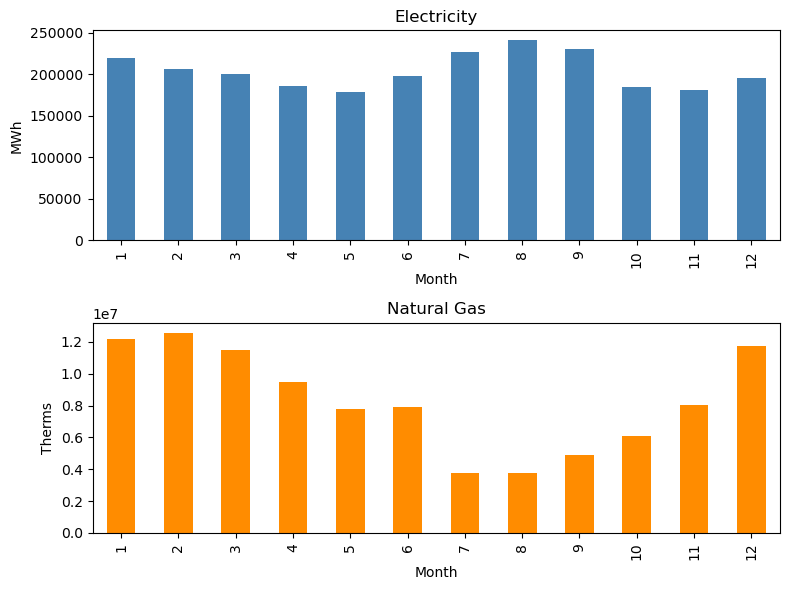

In [55]:
import matplotlib.pyplot as plt

natural_gas_mavg = natural_gas_data.groupby('month')['value'].mean()

electricity_data = data[(data['data_field'] == '3_nat_consumption') & (data['data_field_display_name'] == 'Total Consumption (T)')]
electricity_mavg = electricity_data.groupby('month')['value'].mean()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

electricity_mavg.plot(kind='bar', ax=axes[0], color='steelblue',legend=False)
axes[0].set_title('Electricity')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('MWh')

natural_gas_mavg.plot(kind='bar', ax=axes[1], color='darkorange',legend=False)
axes[1].set_title('Natural Gas')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Therms')

plt.tight_layout()
plt.show()

## 2a.altair 

In [57]:
import altair as alt
df1 = electricity_mavg.reset_index()
df2 = natural_gas_mavg.reset_index()

p1 = alt.Chart(df1).mark_bar().encode(
    x='month:N',
    y='value:Q').properties(
    width=500,
    height=300
)
   

p2 = alt.Chart(df2).mark_bar(color='darkorange').encode(
    x='month:N',y=alt.Y('value:Q', axis=alt.Axis(format='e'))).properties(
    width=500,
    height=300
)

p1 & p2

alt.VConcatChart(...)

## 2b

In [58]:
data

,county_name,data_class,data_field,data_field_display_name,unit,year,month,value,number_of_accounts,date
0,Albany,electricity,11_ny_policy_support,ICAP Capacity Tag (C),MW,2021,7,316.93378,18495.0,2021-07-01
1,Albany,electricity,11_ny_policy_support,ICAP Capacity Tag (C),MW,2021,8,316.86303,18535.0,2021-08-01
2,Albany,electricity,11_ny_policy_support,ICAP Capacity Tag (C),MW,2021,9,316.80300,18460.0,2021-09-01
3,Albany,electricity,11_ny_policy_support,ICAP Capacity Tag (C),MW,2021,10,316.46621,18525.0,2021-10-01
4,Albany,electricity,11_ny_policy_support,ICAP Capacity Tag (C),MW,2021,11,316.66755,18548.0,2021-11-01
...,...,...,...,...,...,...,...,...,...,...
106878,Yates,natural_gas,6_nat_consumption,Total Consumption (T),Therms,2023,8,156252.90000,3437.0,2023-08-01
106879,Yates,natural_gas,6_nat_consumption,Total Consumption (T),Therms,2023,9,193775.00000,3465.0,2023-09-01
106880,Yates,natural_gas,6_nat_consumption,Total Consumption (T),Therms,2023,10,224538.50000,3549.0,2023-10-01
106881,Yates,natural_gas,6_nat_consumption,Total Consumption (T),Therms,2023,11,493544.10000,3273.0,2023-11-01


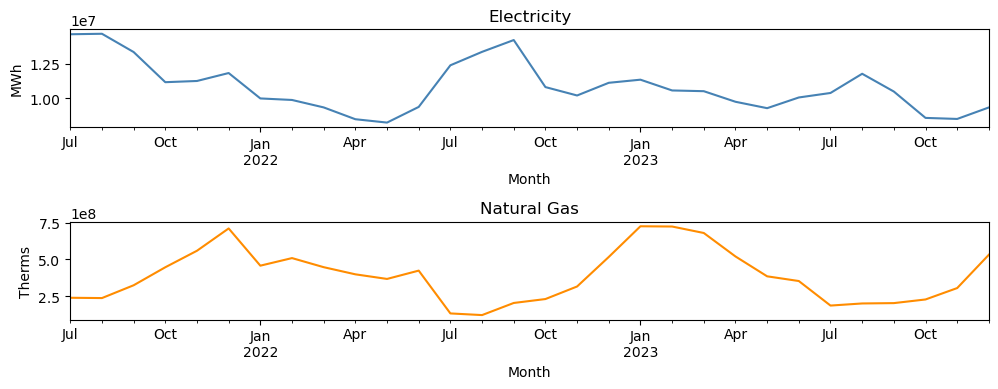

In [59]:

electricity_mtotal = electricity_data.groupby('date')['value'].sum()

natural_gas_mtotal = natural_gas_data.groupby('date')['value'].sum()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 4))

electricity_mtotal.plot( kind='line',ax=axes[0], color='steelblue',  linestyle='-')
axes[0].set_title('Electricity')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('MWh')

natural_gas_mtotal.plot( kind='line',ax=axes[1], color='darkorange', linestyle='-')
axes[1].set_title('Natural Gas')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Therms')


plt.tight_layout()
plt.show()

## 2b altair

In [61]:
df21 = electricity_mtotal.reset_index()
df22 = natural_gas_mtotal.reset_index()

y_axis = alt.Axis(title='MWh', values=list(range(8000000,16000000, 2000000)),format='e')

p1 = alt.Chart(df21).mark_line().encode(
    x=alt.X('date', title='date'),
    y=alt.Y('value:Q', axis=y_axis)).properties(
    width=600,
    height=200,
    title='Electricity'
)

p2 = alt.Chart(df22).mark_line(color='darkorange').encode(
    x='date',y=alt.Y('value:Q', axis=alt.Axis(format='e',title='Therms'))).properties(
    width=600,
    height=200,
    title='Natural_gas'
)

p1 & p2


alt.VConcatChart(...)

## 3a

In [62]:

data_2023 = data[data["year"] == 2023]
electric_data = data_2023[(data_2023['data_field'] == '3_nat_consumption') & (data_2023['data_field_display_name'] == 'Total Consumption (T)')]
naturalgas_data = data_2023[(data_2023['data_field'] == '6_nat_consumption') & (data_2023['data_field_display_name'] == 'Total Consumption (T)')]


In [67]:
full_data=pd.merge(electric_data,naturalgas_data, on=['county_name', 'month'])
x_axis = alt.Axis(title='electricity (MWh)', values=list(range(0, 2000000, 200000)))
y_axis = alt.Axis(title='natural_gas (Therms)', values=list(range(0, 100000000, 10000000)))

In [68]:
plot = alt.Chart(full_data).mark_circle(size=25, color='grey').encode(
    x=alt.X('value_x:Q', axis=x_axis),
    y=alt.Y('value_y:Q', axis=y_axis),
    tooltip=['county_name:N']
).properties(
    width=200,
    height=200
).facet(
    facet=alt.Facet('month:N', title='Month'),
    columns=3
)

plot


alt.FacetChart(...)

In [69]:
hover=alt.selection_point(on='mouseover', fields=['county_name'], empty=False)

plot = alt.Chart(full_data).mark_circle(size=60).encode(
    x=alt.X('value_x:Q', axis=x_axis),
    y=alt.Y('value_y:Q', axis=y_axis),
    color=alt.condition(hover, alt.ColorValue('red'), alt.ColorValue('grey')),
    size=alt.condition(hover, alt.SizeValue(60), alt.SizeValue(25)),
    tooltip=['county_name:N']).properties(width=200,height=200).add_params(hover).facet(facet=alt.Facet('month:N', title='Month'),columns=3)

plot


alt.FacetChart(...)